# Attention ： 注意力机制的构造思路

    Attention的构造思路主要是用一个网络学习一个输入序列的关系时，用一个表征关联性的相关性矩阵来给网络学习到的内容V加权重，重要的拉高一点儿，不重要的拉低一点儿。
    相关性矩阵一定是nxn的方阵，如下例子

    | Query \ Key | [CLS] | 猫 | 吃 | 鱼 | [SEP] |
    | :---        | :--- | :--- | :--- | :--- | :--- |
    | **[CLS]** | 2.1 | 0.5 | 0.3 | 0.4 | 1.8 |
    | **猫** | 0.6 | 3.2 | 2.8 | 1.1 | 0.5 |
    | **吃** | 0.4 | 4.5 | 1.9 | 4.2 | 0.3 |
    | **鱼** | 0.5 | 1.0 | 3.8 | 3.0 | 0.6 |
    | **[SEP]** | 1.9 | 0.4 | 0.3 | 0.5 | 2.2 |


    Q1：为什么需要QK来构造注意力？单一个矩阵S和价值做点积不行吗？
    Q2：注意力机制本质上是一个权重矩阵加权到被注意的信息中，那为什么是对V作注意而不是对原始的X？或者说怎么说明V的表征比原始的S要好？

    A1: 注意力需要$n\times n$的相关性矩阵来表征token之间的相关性，如果只有一个只用一个矩阵S表征注意力，那它必然是$nxn$的，这就要求网络参数尺寸$W\in R_{m\times n}$(假设输入$X\in R_{n\times m}$)，这样注意力网络的参数量就无法固定，需要随着输入长度的变化而变化；
    A2: 尚不明确；

    Q3: 为什么缩放因子scale是$\sqrt{d_k}$?
    A3：缩放因子的目的是归一化，由于$Var(Q.K)=d_k$，为了让点积的方差回到1，所以除以标准差$d_k$

In [7]:
import numpy
import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

In [8]:
class Attention(nn.Module):
    """
        X: (batch_size, seq_len, d_k)
        W: (d_model, d_k)
    """
    def __init__(self, d_model, d_k, dropout=0.1):
        super().__init__()
        self.scale = math.sqrt(d_k)
        self.W_q   = nn.Linear(d_model, d_k)
        self.W_k   = nn.Linear(d_model, d_k)
        self.W_v   = nn.Linear(d_model, d_k)

    def forward(self, X):
        #计算投影
        Q = self.W_q(X)
        K = self.W_k(X)
        V = self.W_v(X)
        #计算相关性分数
        scores = torch.matmul(Q, K.transpose(-2, -1)) / self.scale
        #计算权重矩阵
        R = torch.softmax(scores, dim=-1)
        return torch.matmul(R, V), R


X.shape = torch.Size([2, 5, 16])
output.shape = torch.Size([2, 5, 8])
R.shape = torch.Size([2, 5, 5])
output = tensor([[[-0.0887, -0.1623, -0.2390, -0.2308, -0.5402, -0.2868,  0.2276,
          -0.4366],
         [-0.1907, -0.1644, -0.2119, -0.0575, -0.3504, -0.1804,  0.2264,
          -0.2317],
         [-0.1637, -0.1123, -0.2857, -0.1120, -0.3814, -0.3277,  0.2707,
          -0.3137],
         [-0.0965, -0.1339, -0.2250, -0.1808, -0.5058, -0.2924,  0.2484,
          -0.3843],
         [-0.1769, -0.2410, -0.1436, -0.1121, -0.4569, -0.0762,  0.1472,
          -0.2672]],

        [[-0.3308,  0.8024,  0.1234, -0.1446,  0.0724, -0.7400,  0.0242,
          -0.1909],
         [-0.4259,  0.7643,  0.2190, -0.1355, -0.0676, -0.5578, -0.0404,
          -0.1910],
         [-0.5475,  0.7917,  0.2727, -0.1729, -0.1248, -0.4636, -0.1569,
          -0.2098],
         [-0.4844,  0.7858,  0.1998, -0.1824, -0.0222, -0.5703, -0.0984,
          -0.1694],
         [-0.4422,  0.7780,  0.2106, -0.1517, -0.0

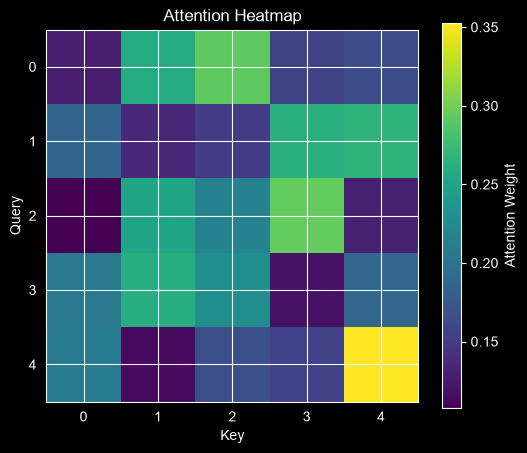

In [9]:
import torch
import matplotlib.pyplot as plt

# 创建 Attention
attention = Attention(
    d_model=16,
    d_k=8
)

# 创建测试输入
X = torch.randn(2, 5, 16)

# 前向计算
output, R = attention(X)

# 打印结果
print("X.shape =", X.shape)
print("output.shape =", output.shape)
print("R.shape =", R.shape)
print("output =", output)

# =========================
# 可视化 Attention 热力图
# =========================

# 取第 0 个 batch
attention_map = R[0].detach().numpy()

plt.figure(figsize=(6, 5))

plt.imshow(
    attention_map,
    cmap="viridis"
)

# 颜色条
plt.colorbar(label="Attention Weight")

# 横纵坐标
plt.xlabel("Key")
plt.ylabel("Query")

# 标题
plt.title("Attention Heatmap")

# token 位置
plt.xticks(range(5))
plt.yticks(range(5))

plt.show()

## 多头注意力
    1. 多头注意力是关注序列里面的不同特征的关联性，例如”猫吃鱼“，第一个头关注语法结构主谓宾：“猫”主语，“吃”动作作谓语，“鱼”宾语，第二个头关注语义类别，比如关注到猫和鱼都是动物，第三个头巴拉巴拉；
    2. 前面实现自注意力的时候，注意到投影矩阵的第二个维度d_k, 把d_k

In [10]:
class MultiHeadAttention(nn.Module):
    """
        X: (batch_size, seq_len, d_model)
        W: (d_model, d_k)
        num_heads: 头数
        d_head = d_k // num_heads: 每个头的维度
    """
    def __init__(self, d_model, d_k, num_heads, dropout=0.1):
        super().__init__()
        assert d_k % num_heads == 0, "d_k 必须能被 num_heads 整除"

        self.d_model = d_model
        self.d_k = d_k
        self.num_heads = num_heads
        self.d_head = d_k // num_heads
        self.scale = math.sqrt(self.d_head)   # 缩放因子用每个头的维度

        # 投影矩阵
        self.W_q = nn.Linear(d_model, d_k)
        self.W_k = nn.Linear(d_model, d_k)
        self.W_v = nn.Linear(d_model, d_k)
        self.W_o = nn.Linear(d_k, d_k)        # 输出投影

        self.dropout = nn.Dropout(dropout)

    def forward(self, X):
        B, n, _ = X.shape

        # 1. 投影
        Q = self.W_q(X)   # [B, n, d_k]
        K = self.W_k(X)   # [B, n, d_k]
        V = self.W_v(X)   # [B, n, d_k]

        # 2. 拆多头
        # [B, n, d_k] -> [B, n, H, d_head] -> [B, H, n, d_head]
        Q = Q.view(B, n, self.num_heads, self.d_head).transpose(1, 2)
        K = K.view(B, n, self.num_heads, self.d_head).transpose(1, 2)
        V = V.view(B, n, self.num_heads, self.d_head).transpose(1, 2)

        # 3. 相关性分数
        # [B, H, n, d_head] @ [B, H, d_head, n] = [B, H, n, n]
        scores = torch.matmul(Q, K.transpose(-2, -1)) / self.scale

        # 4. 权重矩阵
        R = torch.softmax(scores, dim=-1)   # [B, H, n, n]
        R = self.dropout(R)

        # 5. 加权求和
        # [B, H, n, n] @ [B, H, n, d_head] = [B, H, n, d_head]
        out = torch.matmul(R, V)

        # 6. 合并多头
        # [B, H, n, d_head] -> [B, n, H, d_head] -> [B, n, d_k]
        out = out.transpose(1, 2).contiguous().view(B, n, self.d_k)

        # 7. 输出投影
        out = self.W_o(out)   # [B, n, d_k]

        return out, R

In [11]:
if __name__ == "__main__":
    B, n, d_model, d_k, H = 2, 5, 64, 64, 4

    attn = MultiHeadAttention(d_model, d_k, num_heads=H)

    X = torch.randn(B, n, d_model)
    out, R = attn(X)

    print(f"输入: {X.shape}")        # [2, 5, 64]
    print(f"输出: {out.shape}")      # [2, 5, 64]
    print(f"注意力: {R.shape}")      # [2, 4, 5, 5]

    # 验证每行权重和为 1
    print(f"每行和: {R.sum(dim=-1)}")

    # 查看第0个样本第0个头的注意力
    print(f"\n第0个样本第0个头的注意力:\n{R[0, 0]}")

输入: torch.Size([2, 5, 64])
输出: torch.Size([2, 5, 64])
注意力: torch.Size([2, 4, 5, 5])
每行和: tensor([[[0.8616, 0.8346, 1.1111, 1.1111, 1.1111],
         [1.1111, 1.1111, 0.8696, 1.1111, 0.9830],
         [0.4610, 0.8155, 1.1111, 1.1111, 1.1111],
         [1.1111, 0.7574, 0.9237, 1.1111, 0.8500]],

        [[1.1111, 0.9081, 1.1111, 0.8693, 1.1111],
         [1.1111, 1.1111, 1.1111, 1.1111, 1.1111],
         [1.1111, 1.1111, 1.1111, 1.1111, 1.1111],
         [1.1111, 1.1111, 1.1111, 0.8460, 1.1111]]], grad_fn=<SumBackward1>)

第0个样本第0个头的注意力:
tensor([[0.1971, 0.2055, 0.2794, 0.0000, 0.1796],
        [0.2750, 0.2455, 0.0000, 0.1641, 0.1500],
        [0.2306, 0.1985, 0.2968, 0.1827, 0.2025],
        [0.1888, 0.1424, 0.2138, 0.3181, 0.2480],
        [0.2787, 0.1002, 0.2741, 0.3159, 0.1422]], grad_fn=<SelectBackward0>)
